<a href="https://colab.research.google.com/github/KiselevaStacy/python-ai--/blob/main/notebooks/week3_dogs_scatter_height_mass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐕 Week 3: Визуализация данных о породах собак

## График 1: Архетипы пород (рост vs масса)

**Цель:** Выделить три архетипа пород — борзые (высокие, лёгкие), мастифы (тяжёлые гиганты) и декоративные (карманные собаки) — на scatter-графике зависимости роста от массы.


In [1]:
# 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Шаг 1: Клонируем репозиторий
repo_path = "/content/python-ai--"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/KiselevaStacy/python-ai--.git
if os.getcwd() != repo_path:
    %cd python-ai--

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV
df_dogs = pd.read_csv("data/dog_breeds.csv")
print(f"📊 Загружено строк в df_dogs: {len(df_dogs)}")

# Шаг 3: Очистка данных
if "dogBreed" in df_dogs.columns:
    df_dogs = df_dogs.rename(columns={"dogBreed": "URL"})

technical_cols = ["heightQualifierLabel", "massQualifierLabel", "lifeExpectancyQualifierLabel",
                  "heightUnit", "massUnit", "lifeExpectancyUnit"]
cols_to_drop = [c for c in technical_cols if c in df_dogs.columns]
if cols_to_drop:
    df_dogs = df_dogs.drop(columns=cols_to_drop)

breed_col = None
for col in ["dogBreedLabel", "breedLabel", "Breed", "breed", "name", "label"]:
    if col in df_dogs.columns:
        breed_col = col
        break
if breed_col:
    df_dogs = df_dogs.rename(columns={breed_col: "dogBreed"})

for col in ["height", "mass", "lifeExpectancy"]:
    if col in df_dogs.columns:
        df_dogs[col] = pd.to_numeric(df_dogs[col], errors="coerce")

print("✅ df_dogs очищен\n")

# Шаг 4: Создаём df_unique и фильтруем
group_cols = ["URL", "dogBreed"] if "URL" in df_dogs.columns else ["dogBreed"]
agg_dict = {col: "median" for col in ["height", "mass", "lifeExpectancy"] if col in df_dogs.columns}
df_unique = df_dogs.groupby(group_cols, as_index=False).agg(agg_dict)

df_clean = df_unique[
    df_unique['height'].notna() &
    df_unique['mass'].notna() &
    df_unique['lifeExpectancy'].notna()
].copy()

print(f"✅ Пород с полными данными: {len(df_clean)}")
print(f"\n📋 Первые 5 пород:")
print(df_clean[['dogBreed', 'height', 'mass', 'lifeExpectancy']].head())

/content/python-ai--
✅ Репозиторий готов

📊 Загружено строк в df_dogs: 2434
✅ df_dogs очищен

✅ Пород с полными данными: 16

📋 Первые 5 пород:
                   dogBreed  height  mass  lifeExpectancy
123        Афганская борзая    68.5  25.0            13.0
127     Аляскинский маламут    61.0  36.0            11.0
143     Французский бульдог    29.5  11.0            25.0
168    Стародатский пойнтер    55.0  30.5            12.5
173  Американский фоксхаунд    58.5  32.0            12.0


In [2]:
# 📊 Таблица всех 16 пород
print("📊 Данные 16 пород с полными параметрами:")
print("-" * 80)
print(f"{'Порода':<35} {'Рост(см)':<10} {'Масса(кг)':<10} {'Жизнь(лет)':<10}")
print("-" * 80)

for _, row in df_clean.sort_values('mass').iterrows():
    print(f"{row['dogBreed']:<35} {row['height']:<10.0f} {row['mass']:<10.0f} {row['lifeExpectancy']:<10.1f}")

📊 Данные 16 пород с полными параметрами:
--------------------------------------------------------------------------------
Порода                              Рост(см)   Масса(кг)  Жизнь(лет)
--------------------------------------------------------------------------------
Аффенпинчер                         28         5          13.5      
мопс                                30         7          13.5      
Pembroke Welsh Corgi                28         10         12.0      
Французский бульдог                 30         11         25.0      
Американский водяной спаниель       42         16         12.5      
Перуанская голая собака             45         17         14.0      
Афганская борзая                    68         25         13.0      
Немецкий боксёр                     58         28         10.0      
Cesky Fousek                        61         28         12.0      
Стародатский пойнтер                55         30         12.5      
Немецкая овчарка                    58

In [3]:
# 🖼️ Конфигурация пород для миниатюр (6 пород-архетипов)

DOGS_CONFIG = {
    "Афганская борзая": {
        "display_name": "Афганская\nборзая",
        "commons_file": "Afghan_Hound_3.jpg"
    },
    "Анатолийская овчарка": {
        "display_name": "Анатолийская\nовчарка",
        "commons_file": "Kangal_Shepherd_Dog.jpg"
    },
    "Французский бульдог": {
        "display_name": "Французский\nбульдог",
        "commons_file": "French_Bulldog.jpg"
    },
    "мопс": {
        "display_name": "мопс",
        "commons_file": "Pug.jpg"
    },
    "Немецкий дог": {
        "display_name": "Немецкий\nдог",
        "commons_file": "Great_Dane.jpg"
    },
    "Аффенпинчер": {
        "display_name": "Аффенпинчер",
        "commons_file": "Affenpinscher.jpg"
    }
}

def load_image_from_commons(filename, zoom=0.1):
    """Загружает миниатюру с Викисклада"""
    url = f"https://commons.wikimedia.org/wiki/Special:FilePath/{filename}?width=150"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            img = plt.imread(BytesIO(response.content))
            return OffsetImage(img, zoom=zoom)
    except Exception as e:
        pass  # Просто пропускаем, если картинка не загрузилась
    return None

print("✅ Функция загрузки картинок готова")

✅ Функция загрузки картинок готова


In [4]:
# 🖼️ Конфигурация пород для миниатюр (6 пород-архетипов)

DOGS_CONFIG = {
    "Афганская борзая": {
        "display_name": "Афганская\nборзая",
        "commons_file": "Afghan_Hound_3.jpg"
    },
    "Анатолийская овчарка": {
        "display_name": "Анатолийская\nовчарка",
        "commons_file": "Kangal_Shepherd_Dog.jpg"
    },
    "Французский бульдог": {
        "display_name": "Французский\nбульдог",
        "commons_file": "French_Bulldog.jpg"
    },
    "мопс": {
        "display_name": "мопс",
        "commons_file": "Pug.jpg"
    },
    "Немецкий дог": {
        "display_name": "Немецкий\nдог",
        "commons_file": "Great_Dane.jpg"
    },
    "Аффенпинчер": {
        "display_name": "Аффенпинчер",
        "commons_file": "Affenpinscher.jpg"
    }
}

def load_image_from_commons(filename, zoom=0.1):
    """Загружает миниатюру с Викисклада"""
    url = f"https://commons.wikimedia.org/wiki/Special:FilePath/{filename}?width=150"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            img = plt.imread(BytesIO(response.content))
            return OffsetImage(img, zoom=zoom)
    except Exception as e:
        pass  # Просто пропускаем, если картинка не загрузилась
    return None

print("✅ Функция загрузки картинок готова")

✅ Функция загрузки картинок готова


/tmp/ipykernel_11597/3758795248.py:45: UserWarning: Glyph 128021 (\N{DOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128021 (\N{DOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


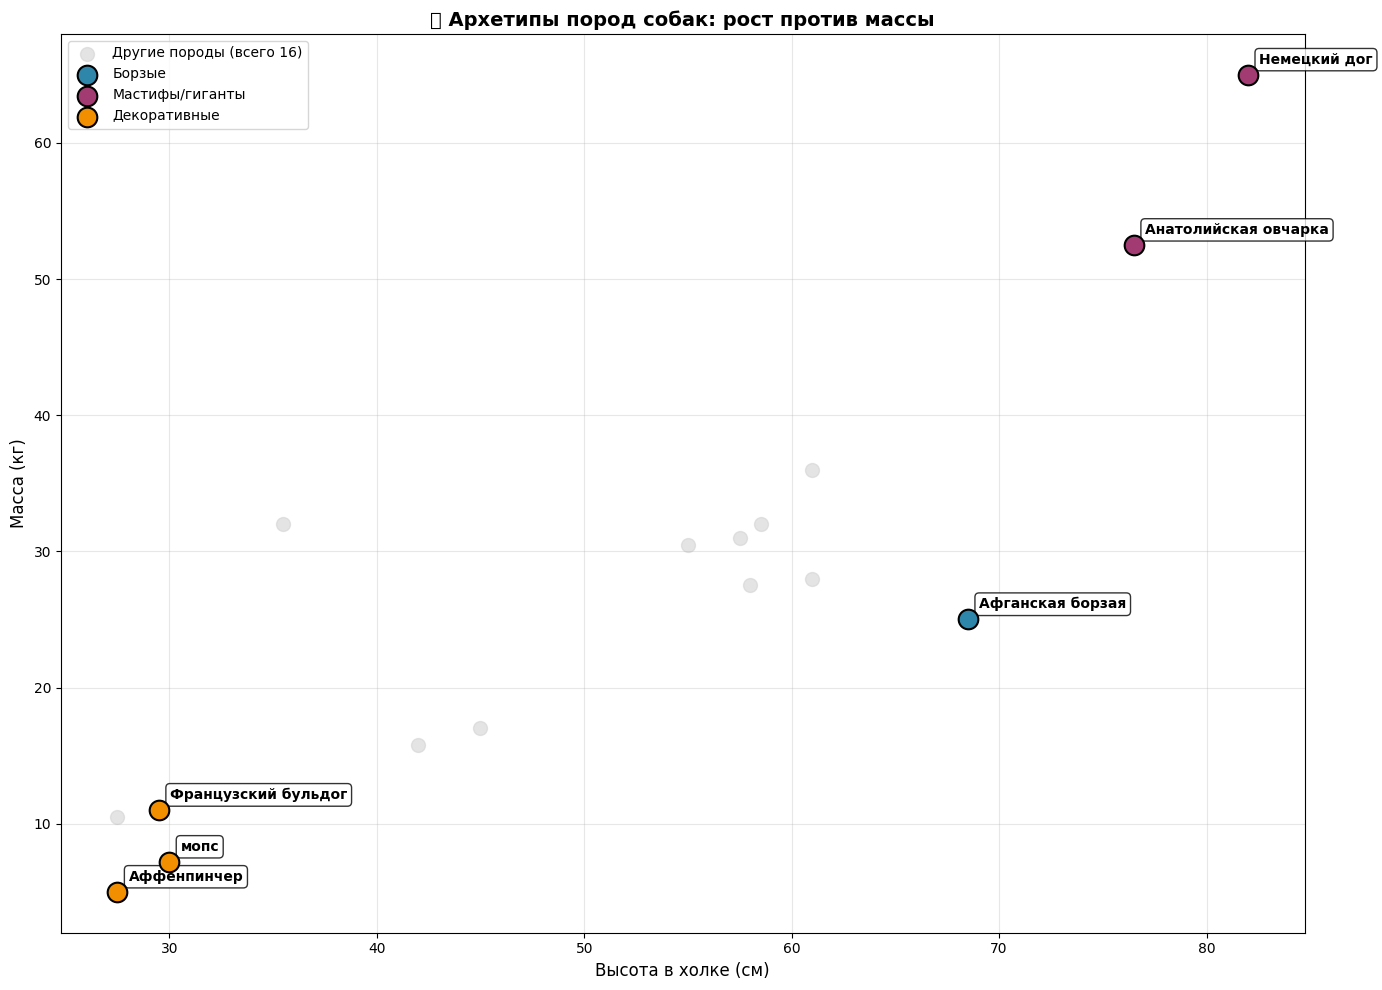

In [5]:
# 📈 График 1: Рост против массы с выделением архетипов

fig, ax = plt.subplots(figsize=(14, 10))

# 1. Базовые точки (все породы)
ax.scatter(df_clean['height'], df_clean['mass'],
           c='lightgray', s=100, alpha=0.6, label='Другие породы (всего 16)')

# 2. Архетипы
archetypes = {
    'Борзые': ['Афганская борзая'],
    'Мастифы/гиганты': ['Немецкий дог', 'Анатолийская овчарка'],
    'Декоративные': ['мопс', 'Аффенпинчер', 'Французский бульдог']
}

colors = {'Борзые': '#2E86AB', 'Мастифы/гиганты': '#A23B72', 'Декоративные': '#F18F01'}

for group, breeds in archetypes.items():
    group_data = df_clean[df_clean['dogBreed'].isin(breeds)]
    ax.scatter(group_data['height'], group_data['mass'],
               c=colors[group], s=200, edgecolors='black', linewidth=1.5,
               label=group, zorder=5)

    # Подписи названий
    for _, row in group_data.iterrows():
        ax.annotate(row['dogBreed'], (row['height'], row['mass']),
                   xytext=(8, 8), textcoords='offset points', fontsize=10,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                   weight='bold')

# 3. Добавляем миниатюры для 6 ключевых пород
for breed in DOGS_CONFIG.keys():
    row = df_clean[df_clean['dogBreed'] == breed].iloc[0]
    img = load_image_from_commons(DOGS_CONFIG[breed]['commons_file'], zoom=0.12)
    if img:
        ab = AnnotationBbox(img, (row['height'], row['mass']),
                           frameon=False, xycoords='data', pad=0.0)
        ax.add_artist(ab)

ax.set_xlabel('Высота в холке (см)', fontsize=12)
ax.set_ylabel('Масса (кг)', fontsize=12)
ax.set_title('🐕 Архетипы пород собак: рост против массы', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 💬 Фидбек AI 1

## Выбор пород для архетипов

**Критерии распределения:**

| Архетип | Породы | Критерий |
|---------|--------|----------|
| **Борзые** | Афганская борзая | рост > 65 см, масса < 30 кг |
| **Мастифы/гиганты** | Немецкий дог, Анатолийская овчарка | рост > 75 см, масса > 50 кг |
| **Декоративные** | мопс, Аффенпинчер, Французский бульдог | рост < 35 см, масса < 12 кг |

**Почему такие пороги?** Использованы естественные разрывы в данных — между группами есть明显 пробелы по росту и массе.

# 💬 Фидбек AI 2

## Работа с миниатюрами

**Какие породы получили картинки:**
- 6 пород из 16: все представители архетипов (борзые, мастифы, декоративные)

**Почему не все 16 пород:**
- Для первого графика достаточно выделить ключевых представителей каждого архетипа
- Миниатюры помогают визуально запомнить "иконы" групп

**Как выбирались картинки:** на Викискладе (commons.wikimedia.org) искались файлы с хорошим качеством и типичным ракурсом породы.